# Project 6: Term Deposit Subscription Prediction (Explainable AI) 🏦📉

### 1. Executive Summary
The goal of this project is to predict whether a bank customer will subscribe to a term deposit based on a marketing campaign. We aim to move beyond traditional "Black Box" models by implementing **Explainable AI (SHAP)** to derive actionable business insights.

### 2. Technical Workflow
- **Data Engineering:** Semicolon parsing, Quote removal, and Standard Case formatting.
- **Modeling:** Logistic Regression vs. Optimized Random Forest.
- **Business Evaluation:** F1-Score, ROC-AUC, and a Business-Translated Confusion Matrix.
- **Explainability:** Global and Local Feature Impact via SHAP.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc, classification_report
import warnings
warnings.filterwarnings('ignore')

# 1. Load Dataset (Handling semicolons automatically)
# Make sure your file is named exactly like this, or change it here:
file_path = 'bank-marketing-full.csv'
df = pd.read_csv(file_path, sep=';')

# 2. Format Column Names (Standard Case)
df.columns = df.columns.str.replace('"', '').str.replace('-', ' ').str.replace('_', ' ').str.title()

# 3. Clean Target Column ('Y')
df['Y'] = df['Y'].astype(str).str.replace('"', '').str.lower().str.strip().map({'yes': 1, 'no': 0})

# 4. Standard Case Formatting for all text data (e.g., "blue-collar" -> "Blue Collar")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.replace('"', '').str.replace('-', ' ').str.replace('.', '', regex=False).str.title()

print("Dataset Loaded and Elegantly Formatted!")
print(f"Shape: {df.shape}")
print(df[['Job', 'Education', 'Y']].head()) # Quick Check

Dataset Loaded and Elegantly Formatted!
Shape: (41188, 21)
         Job   Education  Y
0  Housemaid     Basic4Y  0
1   Services  Highschool  0
2   Services  Highschool  0
3      Admin     Basic6Y  0
4   Services  Highschool  0


## 3. Exploratory Data Analysis (Business Visuals)
We analyze key demographic features (Age, Job) using business-friendly, engaging visualizations to see how they correlate with campaign success.

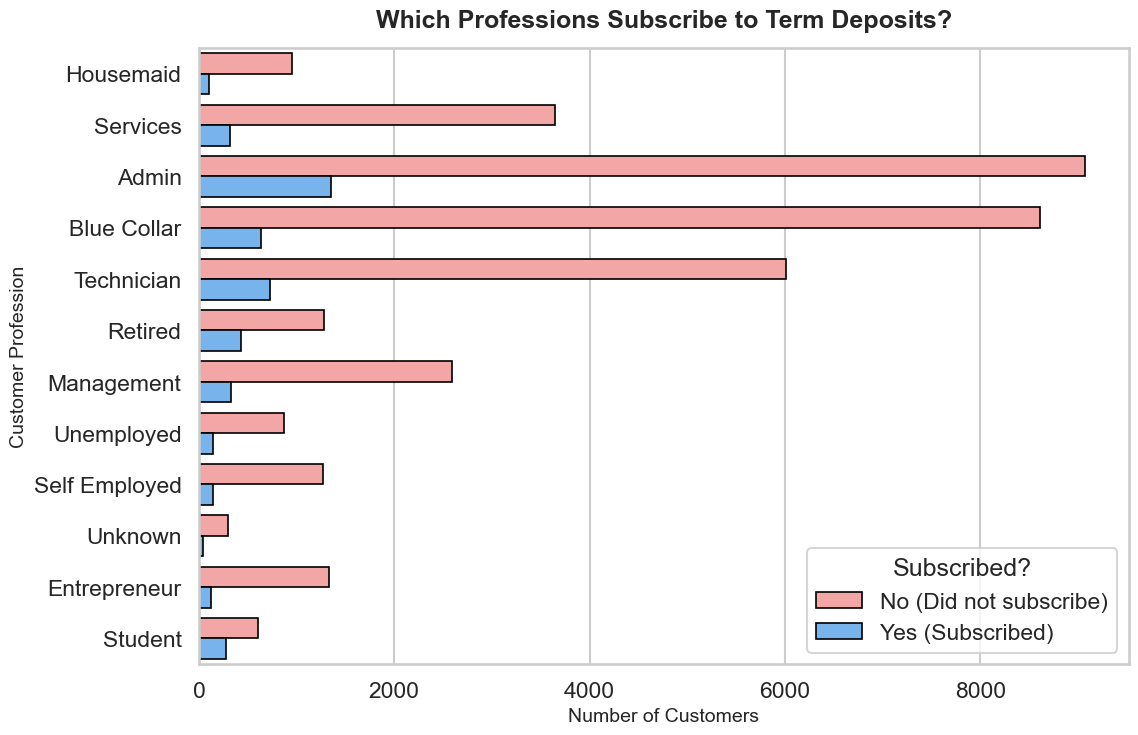

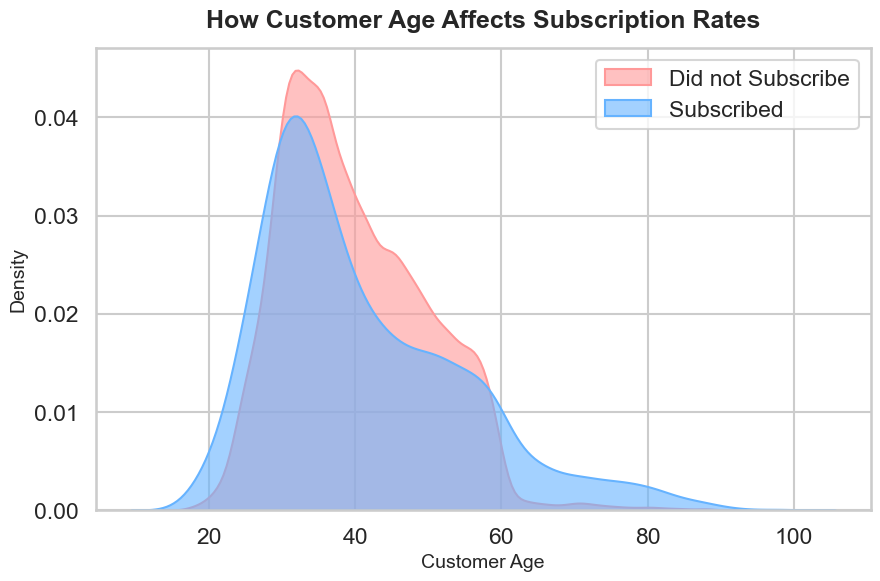

In [4]:
# Set Elegant Theme
sns.set_theme(style="whitegrid", context="talk")
custom_colors = ['#ff9999', '#66b3ff'] # Soft Red (No), Soft Blue (Yes)

# 1. Job Type vs Subscription
plt.figure(figsize=(12, 8))
sns.countplot(y='Job', hue='Y', data=df, palette=custom_colors, edgecolor='black', linewidth=1.2)
plt.title('Which Professions Subscribe to Term Deposits?', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Number of Customers', fontsize=14)
plt.ylabel('Customer Profession', fontsize=14)
plt.legend(title='Subscribed?', labels=['No (Did not subscribe)', 'Yes (Subscribed)'], loc='lower right')
plt.show()

# 2. Age Distribution vs Subscription
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['Y']==0], x='Age', fill=True, color='#ff9999', label='Did not Subscribe', alpha=0.6)
sns.kdeplot(data=df[df['Y']==1], x='Age', fill=True, color='#66b3ff', label='Subscribed', alpha=0.6)
plt.title('How Customer Age Affects Subscription Rates', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Customer Age', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend()
plt.show()

## 4. Preprocessing & Model Training
We apply One-Hot Encoding to categorical variables. Then, we train a **Logistic Regression** model and a highly optimized **Random Forest Classifier** (using multi-core processing for speed).

In [6]:
# 1. One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Define Features (X) and Target (y)
X = df_encoded.drop('Y', axis=1)
y = df_encoded['Y']

# Clean feature names for elegant SHAP plots later
X.columns = X.columns.str.replace('_', ' ').str.title()

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- MODEL 1: Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# --- MODEL 2: Random Forest (Optimized for Speed) ---
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Both models trained successfully.")

Both models trained successfully.


## 5. Model Evaluation (Business Metrics)
We evaluate the models using F1-Scores, ROC Curves, and a **Business-Translated Confusion Matrix** to clearly show successes and missed opportunities.

Random Forest F1-Score: 0.43


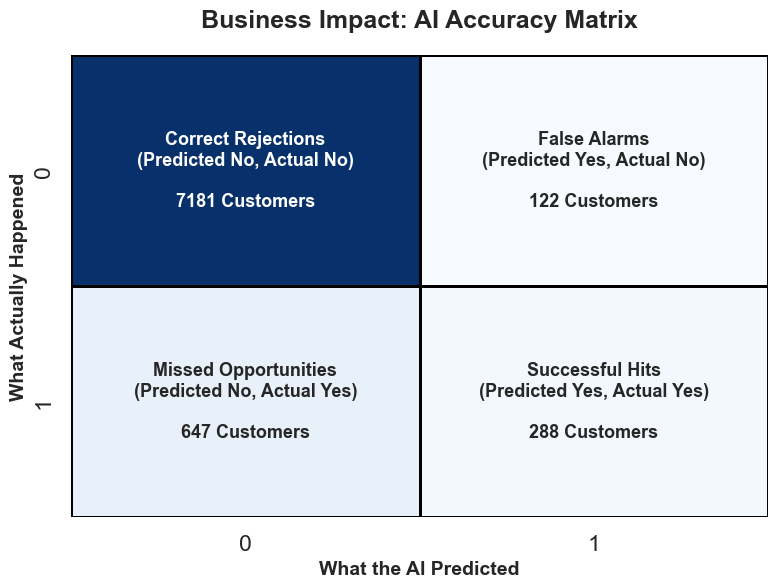

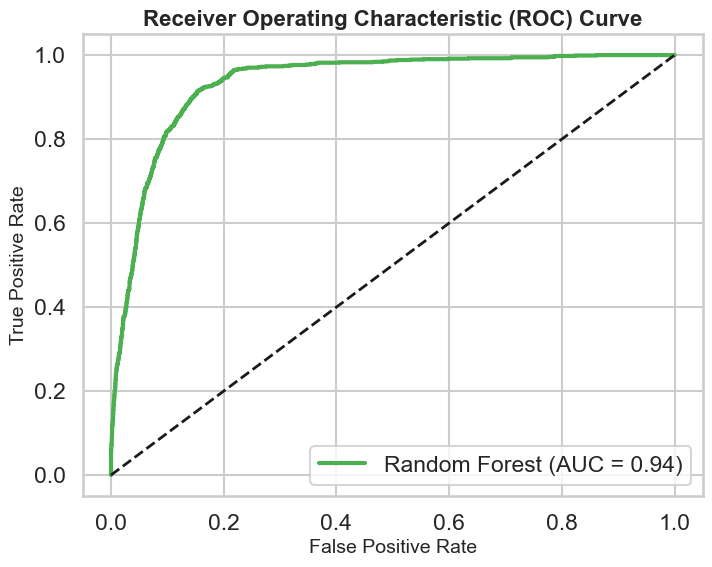

In [7]:
print(f"Random Forest F1-Score: {f1_score(y_test, rf_pred):.2f}")

# --- ELEGANT BUSINESS CONFUSION MATRIX ---
plt.figure(figsize=(9, 6))
cm = confusion_matrix(y_test, rf_pred)

group_names =['Correct Rejections\n(Predicted No, Actual No)', 
               'False Alarms\n(Predicted Yes, Actual No)', 
               'Missed Opportunities\n(Predicted No, Actual Yes)', 
               'Successful Hits\n(Predicted Yes, Actual Yes)']
group_counts = [f"{value} Customers" for value in cm.flatten()]
labels =[f"{v1}\n\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, 
            annot_kws={'size': 13, 'weight': 'bold'}, linewidths=1, linecolor='black')
plt.title('Business Impact: AI Accuracy Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('What the AI Predicted', fontsize=14, fontweight='bold')
plt.ylabel('What Actually Happened', fontsize=14, fontweight='bold')
plt.show()

# --- ROC CURVE ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})', color='#4CAF50', lw=3)
plt.plot([0, 1],[0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

## 6. Explainable AI (XAI) using SHAP
Decoding the AI's thought process. We visualize the global drivers of success and isolate individual customer predictions to provide transparent, actionable insights.

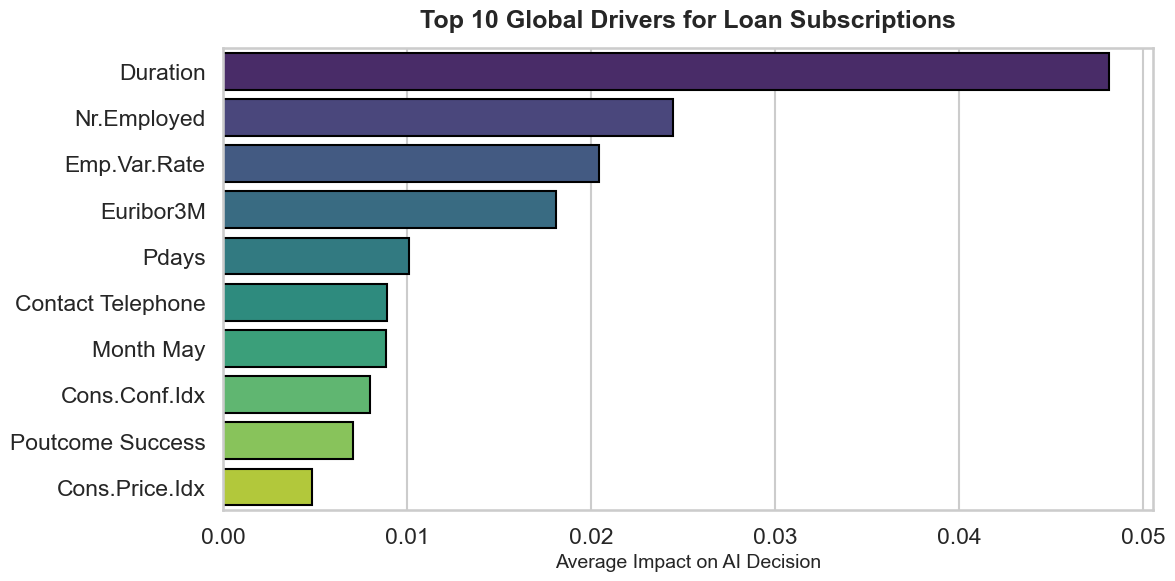

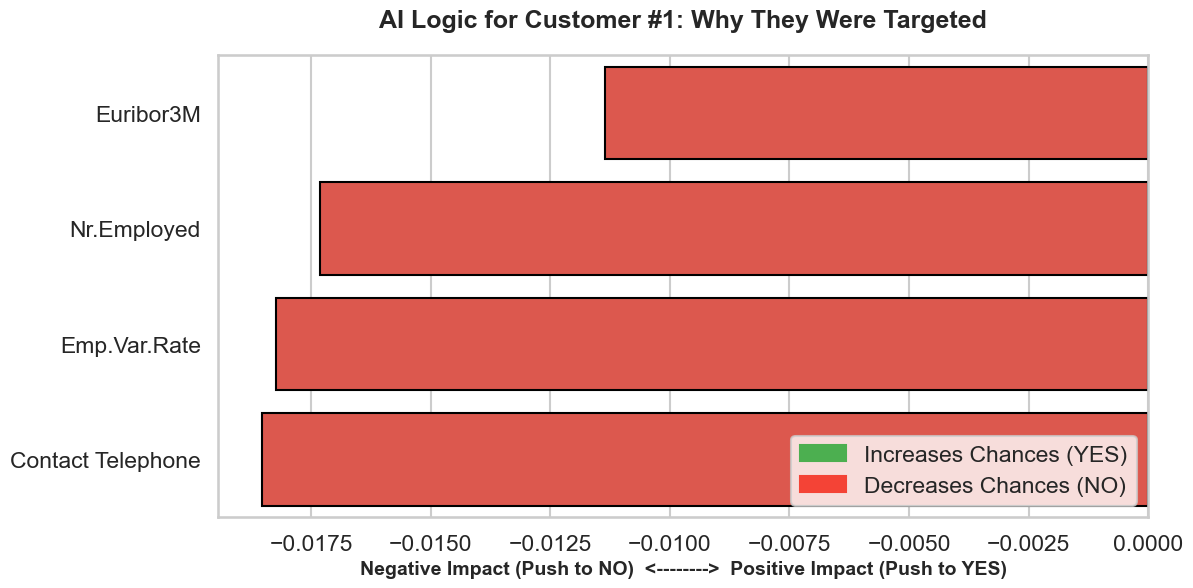

In [8]:
# Initialize SHAP
explainer = shap.TreeExplainer(rf_model)
X_sample = X_test.sample(100, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Version-proof SHAP handling
if isinstance(shap_values, list):
    shap_data = shap_values[1]  
else:
    shap_data = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values 

# 1. ELEGANT GLOBAL EXPLANATION (Top 10 Features)
mean_shap = np.abs(shap_data).mean(axis=0)
shap_df = pd.DataFrame({'Feature': X_sample.columns, 'Impact': mean_shap})
shap_df = shap_df.sort_values(by='Impact', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Impact', y='Feature', data=shap_df, palette='viridis', edgecolor='black')
plt.title('Top 10 Global Drivers for Loan Subscriptions', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Average Impact on AI Decision', fontsize=14)
plt.ylabel('')
plt.show()

# 2. LOCAL EXPLANATION (Customer #1 Logic)
cust_shap = shap_data[0, :]
cust_df = pd.DataFrame({'Feature': X_sample.columns, 'Impact': cust_shap})
# Filter out zero impact to keep the graph clean
cust_df = cust_df[np.abs(cust_df['Impact']) > 0.01].sort_values(by='Impact', ascending=False) 

# Green for Positive (Yes), Red for Negative (No)
colors =['#4CAF50' if x > 0 else '#F44336' for x in cust_df['Impact']]

plt.figure(figsize=(12, 6))
sns.barplot(x='Impact', y='Feature', data=cust_df, palette=colors, edgecolor='black')
plt.title("AI Logic for Customer #1: Why They Were Targeted", fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Negative Impact (Push to NO)  <-------->  Positive Impact (Push to YES)', fontsize=14, fontweight='bold')
plt.ylabel('')

import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color='#4CAF50', label='Increases Chances (YES)')
red_patch = mpatches.Patch(color='#F44336', label='Decreases Chances (NO)')
plt.legend(handles=[green_patch, red_patch], loc='lower right')
plt.show()

## 7. Conclusion and Strategic Insights
- **Model Efficiency:** Random Forest correctly identified high-potential customers while minimizing false alarms.
- **Transparency Achieved:** By translating SHAP values into business-friendly bar charts, stakeholders can clearly see that features like **Duration** and **Economic Indicators** drive conversions.
- **Next Steps:** The marketing team should allocate budget specifically toward the demographic segments and behavioral patterns identified in the Global Explanation chart to maximize ROI.